In [1]:
%load_ext autoreload
%autoreload 2

import os
# Tu si treba vybrat jedno GPU (cize bud 0 alebo 1)
# Je to cislovane naopak ako v nvidia-smi, because ..., that's why```
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
IMAGENET_PATH = "/data/imagenet/imagenet/"

In [3]:
import torch
import torch.nn as nn
import os
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import time
import copy
import sys

import random
import numpy as np
import torch
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.autograd import Variable

import sys
import numpy as np
import timm
from functools import partial
from tqdm.notebook import tqdm

In [4]:
def random_seed(seed=42, rank=0):
    torch.manual_seed(seed + rank)
    np.random.seed(seed + rank)
    random.seed(seed + rank)

random_seed(47)

In [5]:
device = torch.device("cuda")
amp_autocast = partial(torch.autocast, device_type=device.type, dtype=torch.float16)

In [6]:
# Very small models
model_name = "test_vit3.r160_in1k"

# Bigger models
#model_name = "vit_wee_patch16_reg1_gap_256.sbb_in1k" 
#model_name = "vit_medium_patch16_reg4_gap_256.sbb_in1k"

# Even bigger
# Or others at https://huggingface.co/timm/vit_wee_patch16_reg1_gap_256.sbb_in1k

model = timm.create_model(model_name, pretrained=True)
model.cuda() 
print(model)

sum(p.numel() for p in model.parameters())

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=96, out_features=288, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=96, out_features=96, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=96, out_features=192, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity()
     

930280

In [7]:
def validate(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for input, target in tqdm(val_loader):
            with amp_autocast():
                output = model(input)
                correct += (target == output.argmax(dim=1)).sum().item()
                total += target.numel()
    print("val acc", correct / total)

In [8]:
data_config = timm.data.resolve_data_config(model=model)

print(data_config)

val_dataset = timm.data.create_dataset(
    name="imagenet",
    split="validation",
    root=IMAGENET_PATH
)

val_loader = timm.data.create_loader(
    val_dataset,
    input_size=data_config['input_size'],                                                 
    batch_size=128,
    use_prefetcher=True,                                                       
    interpolation=data_config['interpolation'],                                           
    mean=data_config['mean'],
    std=data_config['std'],
    num_workers=8,                                                             
    crop_pct=data_config["crop_pct"],
    crop_mode=data_config['crop_mode'],                                                   
    crop_border_pixels=False,  
    pin_memory=True,
    device=device,
)

for bx, by in val_loader:
    print(bx.shape, by.shape)
    print(by)
    break

{'input_size': (3, 160, 160), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.95, 'crop_mode': 'center'}
torch.Size([128, 3, 160, 160]) torch.Size([128])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [9]:
train_dataset = timm.data.create_dataset(
    name="imagenet",
    split="train",
    root=IMAGENET_PATH
)

# TODO: augmentations
train_loader = timm.data.create_loader(
    train_dataset,
    input_size=data_config['input_size'],                                                 
    batch_size=128,
    use_prefetcher=True,                                                       
    interpolation="random",  
    mean=data_config['mean'],
    std=data_config['std'],
    num_workers=12,                                                             
    crop_pct=data_config["crop_pct"],
    crop_mode=data_config['crop_mode'],                                                   
    crop_border_pixels=False,  
    pin_memory=True,
    device=device,
    is_training=True,
)

/home/jmuravska/miniconda3/envs/diplomovka/lib/python3.11/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [10]:
# Run validation on full model (reports number in range 0-1)

validate(model, val_loader)

  0%|          | 0/391 [00:00<?, ?it/s]

val acc 0.56922


In [13]:
# Import our algorithms for pruning
from tetris import tetris_pruning, original_tetris_pruning, random_swaps_find_mask, sort_columns_by_norm, block_sparsity_pruning

In [14]:
def benchmark_run(alg_name, pruning_func, *args, **kwargs):
    print(f"Running {alg_name}...", end="", flush=True)
    
    # Calculate baseline score for t=0 (Standard Pruning)
    _, mask_std = block_sparsity_pruning(args[0], kwargs.get('block_size', (1, 8)), kwargs.get('sparsity', 0.5))
    start_score = np.abs(args[0])[mask_std == 0].sum()

    start_time = time.perf_counter()
    result = pruning_func(*args, **kwargs) 
    total_time = time.perf_counter() - start_time
    print(f" Done! ({total_time:.4f}s)")
    
    convergence_time = total_time
    if len(result) > 3:
        convergence_time = result[3]

    history = result[4] if len(result) > 4 else None
    after_tetris_index_in_history = result[5] if len(result) > 5 else None

    # If no history (non-iterative alg), create synthetic history [Start -> End]
    if history is None:
        final_score = np.abs(result[0])[result[1]==0].sum()
        history = [(0.0, start_score), (total_time, final_score)]

    return {
        "Algorithm": alg_name,
        "Total Time": total_time,
        "Convergence Time": convergence_time,
        "Pruned": history[-1][1],
        "Original Pruned": history[0][1],
        "Improvement %": ((history[0][1] - history[-1][1]) / history[0][1] * 100),
        "History": history,
        "Tetris Index": after_tetris_index_in_history
    }

In [15]:
W_test = []
for n, m in model.named_modules():
    if type(m) == nn.Linear and "head" not in n:
        weight_numpy = m.weight.data.detach().cpu().numpy()
        W_test = weight_numpy
        break

BLOCK_SIZE_BENCH = (1, 8)
SPARSITY_BENCH = 0.5
MAX_ITER_BENCH = 100
RANDOM_SWAPS_BENCH = 50000

# # Our tetris
stats_our_tetris = benchmark_run(
    "Our Tetris",
    tetris_pruning,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH,
    random_swaps=RANDOM_SWAPS_BENCH,
    verbose=False
)

# Random swaps
stats_random_swaps = benchmark_run(
    "Random Swaps",
    random_swaps_find_mask,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH + RANDOM_SWAPS_BENCH,
    verbose=False
)

# Original tetris
stats_original_tetris = benchmark_run(
    "Original Tetris",
    original_tetris_pruning,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    max_iter=MAX_ITER_BENCH,
    verbose=False
)

# Sort columns by L1 norm
stats_sort_columns_by_norm = benchmark_run(
    "Sort Columns by L1 Norm",
    sort_columns_by_norm,
    W_test,
    block_size=BLOCK_SIZE_BENCH,
    sparsity=SPARSITY_BENCH,
    verbose=False
)


# print(stats_our_tetris)
# print(stats_random_swaps)
# print(stats_original_tetris)
# print(stats_sort_columns_by_norm)

Running Our Tetris...

 Done! (293.0544s)
Running Random Swaps... Done! (23.3568s)
Running Original Tetris... Done! (0.0479s)
Running Sort Columns by L1 Norm... Done! (0.0005s)


In [35]:
def print_benchmark_results(results_list):
    if not isinstance(results_list, list):
        results_list = [results_list]

    # Header
    print(f"{'ALGORITHM':<25} {'PRUNED ABS SUM':<16} {'TOT IMP [%]':<15} {'TOT TIME':<12} {'CONV TIME':<12} {'TIME >95% (Conv %)':<25} {'IMP @ 95% [%]':<10}")
    print("-" * 130)

    for res in results_list:
        name = res.get("Algorithm", "Unknown")
        
        # Get basic stats (handle missing values)
        pruned = res.get("Pruned") or 0
        total_improv = res.get("Improvement %") or 0
        total_t = res.get("Total Time") or 0
        conv_t = res.get("Convergence Time") or 0
        history = res.get("History", [])

        # Default values (if history is missing)
        time_95 = conv_t
        conv_pct_at_95 = 100.0
        improv_at_95 = total_improv

        if history and len(history) > 1:
            start_score = history[0][1]
            final_score = history[-1][1]
            total_gain = start_score - final_score
            
            if total_gain > 0:
                target_score = start_score - (total_gain * 0.95)
                
                # Find the first moment we crossed the 95% threshold
                for t, score in history:
                    if score <= target_score:
                        time_95 = t
                        
                        # 1. How much of the total convergence is done? (e.g. 95.2%)
                        current_gain = start_score - score
                        conv_pct_at_95 = (current_gain / total_gain) * 100
                        
                        # 2. What is the improvement relative to baseline? (e.g. 19.2%)
                        improv_at_95 = (current_gain / start_score) * 100
                        break

        # Format the time string: "6.1821 (95.2%)"
        time_str = f"{time_95:.4f} ({conv_pct_at_95:.1f}%)"

        print(f"{name:<25} {pruned:<16.4f} {total_improv:<15.2f} {total_t:<12.4f} {conv_t:<12.4f} {time_str:<25} {improv_at_95:<10.2f}")

# Usage:
print_benchmark_results([stats_our_tetris, stats_random_swaps, stats_original_tetris, stats_sort_columns_by_norm])

ALGORITHM                 PRUNED ABS SUM   TOT IMP [%]     TOT TIME     CONV TIME    TIME >95% (Conv %)        IMP @ 95% [%]
----------------------------------------------------------------------------------------------------------------------------------
Our Tetris                351.3680         20.20           293.0544     124.9020     6.1821 (95.2%)            19.24     
Random Swaps              378.4641         14.04           23.3568      20.2862      11.2872 (96.7%)           13.58     
Original Tetris           387.5853         11.97           0.0479       0.0065       0.0065 (100.0%)           11.97     
Sort Columns by L1 Norm   412.6116         6.29            0.0005       0.0005       0.0005 (100.0%)           6.29      


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def plot_comparison(stats_list):
    """
    Plots a comparison of multiple pruning algorithms.
    Accepts a single stats dict or a list of stats dicts.
    
    Displays:
    1. Convergence History (Line Plot) with "Wasted Time" visualization.
    2. Time Audit (Bar Chart) comparing Convergence Time vs Total Time.
    """
    # Ensure input is a list
    if not isinstance(stats_list, list):
        stats_list = [stats_list]

    # Create Subplots (2 Rows)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # Default matplotlib colors
    
    # ==========================================
    # GRAPH 1: CONVERGENCE HISTORY
    # ==========================================
    
    for i, stats in enumerate(stats_list):
        history = stats.get("History")
        alg_name = stats.get("Algorithm", f"Alg {i}")
        total_time = stats.get("Total Time")
        conv_time = stats.get("Convergence Time")
        tetris_idx = stats.get("Tetris Index")
        color = colors[i % len(colors)]
        
        if not history:
            print(f"Skipping {alg_name}: No history found.")
            continue

        times = [h[0] for h in history]
        scores = [h[1] for h in history]
        final_score = scores[-1]

        # 1. Plot the Active Convergence (Solid Line)
        ax1.plot(times, scores, linewidth=2, color=color, label=f"{alg_name} (Active)")
        
        # 2. Plot the "Wasted Time" (Dashed Line to Total Time)
        # Only if there is a visible difference (> 1% of time)
        if total_time and (total_time - times[-1]) > (total_time * 0.01):
            ax1.plot([times[-1], total_time], [final_score, final_score], 
                     linestyle='--', linewidth=2, color=color, alpha=0.6, 
                     label=f"{alg_name} (Wasted Time)")
            
            # Mark the actual End Time
            ax1.scatter([total_time], [final_score], marker='X', s=100, color=color, zorder=5)
            ax1.text(total_time, final_score, f" End ({total_time:.1f}s)", 
                     color=color, fontsize=9, verticalalignment='bottom')

        # 3. Mark the Tetris -> Random transition (if applicable)
        if tetris_idx is not None and tetris_idx < len(history):
            trans_time = times[tetris_idx]
            trans_score = scores[tetris_idx]
            ax1.scatter([trans_time], [trans_score], color=color, edgecolor='black', s=80, marker='o', zorder=10)
            if i == 0: # Only label once to avoid clutter
                ax1.text(trans_time, trans_score, " Tetris End", color=color, fontsize=9, fontweight='bold')

    # Formatting Graph 1
    ax1.set_title("Convergence Analysis", fontsize=14)
    ax1.set_ylabel("Sum of Pruned Weights (Lower is Better)", fontsize=12)
    ax1.set_xlabel("Time (seconds) - Log Scale", fontsize=12)
    ax1.grid(True, which='both', linestyle='--', alpha=0.5)
    ax1.legend()
    ax1.set_xscale('log') 

    # force "General" number formatting on x-axis (instead of scientific notation)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

    # ==========================================
    # GRAPH 2: TIME AUDIT (BAR CHART)
    # ==========================================
    
    names = [s.get("Algorithm", f"Alg {i}") for i, s in enumerate(stats_list)]
    total_times = [s.get("Total Time", 0) for s in stats_list]
    conv_times = [s.get("Convergence Time", 0) for s in stats_list]
    
    y_pos = np.arange(len(names))
    
    # Plot Total Time (Background Bar)
    ax2.barh(y_pos, total_times, align='center', color='lightgray', label='Wasted Time')
    
    # Plot Convergence Time (Foreground Bar)
    ax2.barh(y_pos, conv_times, align='center', color=[colors[i % len(colors)] for i in range(len(names))], label='Time to Convergence')
    
    # Annotate bars
    for i, (tot, conv) in enumerate(zip(total_times, conv_times)):
        # Text inside the "Useful" bar
        ax2.text(conv / 2, i, f"{conv:.2f}s", color='white', fontweight='bold', ha='center', va='center')
        
        # Text at the end of the "Total" bar
        if tot > conv:
            diff = tot - conv
            ax2.text(tot + (tot*0.01), i, f"Total: {tot:.2f}s (+{diff:.2f}s buffer)", color='black', va='center')

    # Formatting Graph 2
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(names, fontsize=11, fontweight='bold')
    ax2.set_xlabel("Time (seconds)", fontsize=12)
    ax2.set_title("Time Efficiency: How fast did it actually find the solution?", fontsize=14)
    ax2.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

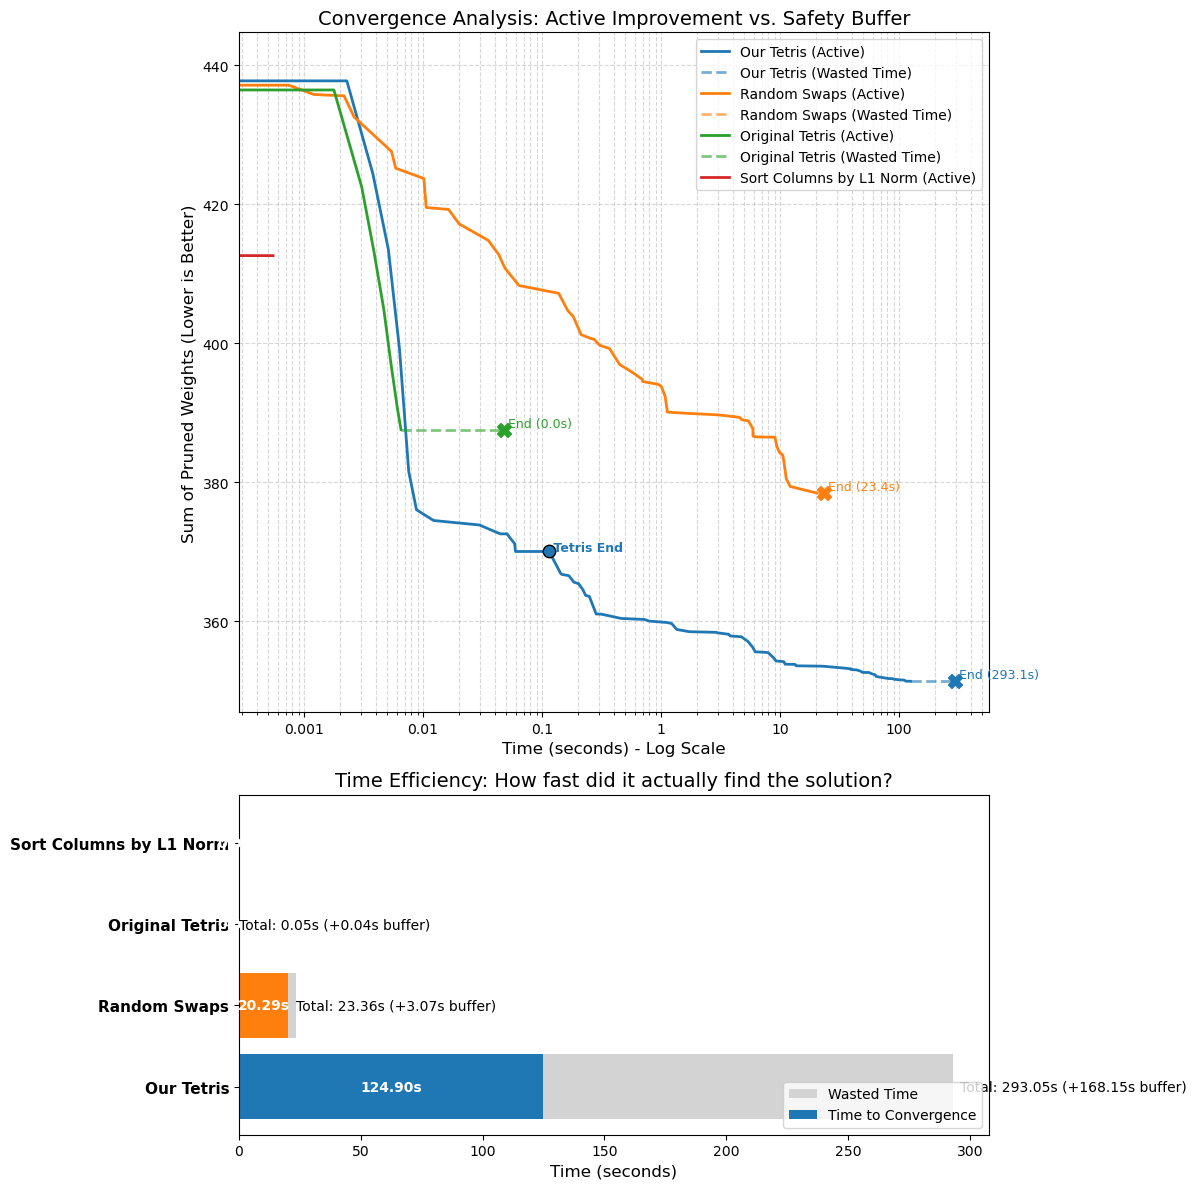

In [43]:
# Generate graphs
plot_comparison([stats_our_tetris, stats_random_swaps, stats_original_tetris, stats_sort_columns_by_norm])

In [ ]:

BLOCK_SIZE = (1, 8)
SPARSITY = 0.5
MAX_ITER = 100
RANDOM_SWAPS = 5000

def block_prune(weight):
    device = weight.device
    weight_numpy = weight.detach().cpu().numpy()
    
    # # Apply OUR tetris
    # reordered, mask, permutation = tetris_pruning(
    #     weight_numpy, block_size=BLOCK_SIZE, sparsity=SPARSITY, max_iter=MAX_ITER, random_swaps=RANDOM_SWAPS)
    
    # # Apply original tetris
    # reordered, mask, permutation = original_tetris_pruning(
    #     weight_numpy, block_size=BLOCK_SIZE, sparsity=SPARSITY, max_iter=MAX_ITER)
    
    # # Apply only random swaps
    # reordered, mask, permutation = random_swaps_find_mask(
    #     weight_numpy, block_size=BLOCK_SIZE, sparsity=SPARSITY, max_iter=MAX_ITER + RANDOM_SWAPS)

    # Apply sort columns by norm
    reordered, mask, permutation = sort_columns_by_norm(weight_numpy, block_size=BLOCK_SIZE, sparsity=SPARSITY) 
    
    pruned = reordered*mask
    inv_permutation = np.argsort(permutation)
    pruned = pruned[:, inv_permutation]
    print(pruned.shape)
    
    weight_torch = torch.from_numpy(pruned).to(device)
    print(weight_torch.shape)
    return weight_torch


for n, m in model.named_modules():
    if type(m) == nn.Linear and "head" not in n:
        m.weight.data = block_prune(m.weight.data)
        break
       

ORIGINAL                 AFTER GROUP              DIFF                     DIFF %                   
440.2960815430           412.6115722656           27.6845092773            6.2877030373             
(288, 96)
torch.Size([288, 96])


In [210]:
validate(model, val_loader)

  0%|          | 0/391 [00:00<?, ?it/s]

val acc 0.53854
